Current notebook path: /home/luky/skola/KalmanNet-main/navigation NCLT dataset
Modul 'utils' úspěšně importován!
Hledám data na cestě: /home/luky/skola/KalmanNet-main/navigation NCLT dataset/data/processed/test.pt
--> Data úspěšně načtena! Nalezeno trajektorií: 3
--> KML uložen do: QGIS/2012-11-16_Map.kml
--> 2D mapa pro diplomku uložena do: NCLT_Graphs/2012-11-16_2D_Map.pdf


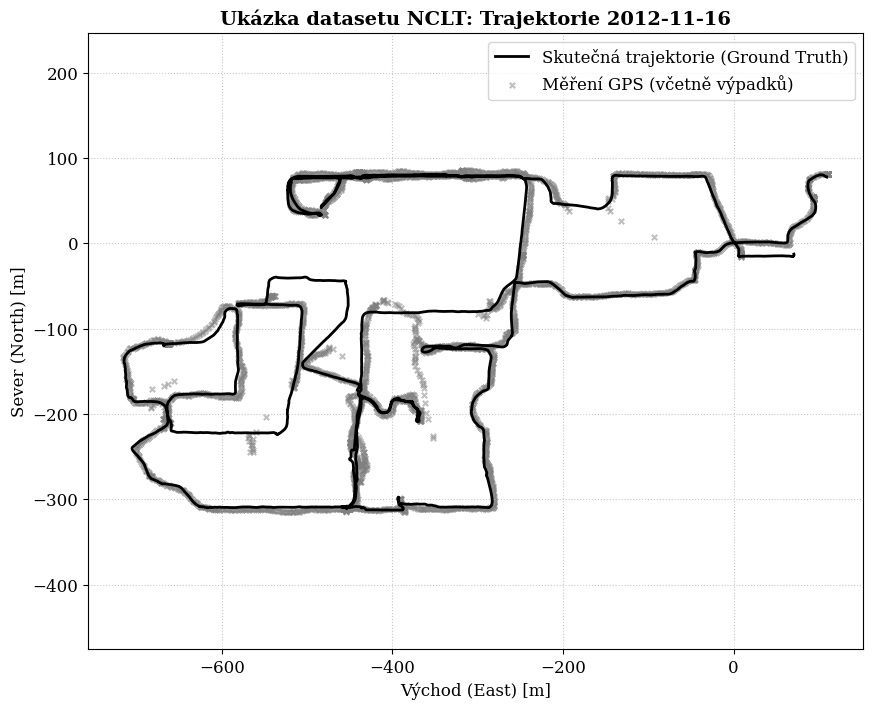

In [11]:
from pathlib import Path
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from lxml import etree

# ==============================================================================
# 1. OPRAVA CESTY PRO IMPORTY
# ==============================================================================
nb_dir = Path.cwd()
print(f"Current notebook path: {nb_dir}")

# Oprava: Chceme jít pouze o 1 úroveň nahoru (do složky KalmanNet-main)
repo_root = nb_dir.parent 

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
    print(f"Added {repo_root} to sys.path")

# Pokud máš utils, můžeš je teď importovat, i když pro tento skript 
# s KML exportem je nutně nepotřebuješ.
try:
    from utils import utils
    print("Modul 'utils' úspěšně importován!")
except ModuleNotFoundError:
    print("Varování: Modul 'utils' stále nenalezen. Pro KML export to ale nevadí.")

# ==============================================================================
# 2. NAČTENÍ DAT (test_data_raw)
# ==============================================================================
# Z tvého preprocesing skriptu víme, že se to ukládalo do složky data/NCLT/processed/
# Cestu případně uprav, pokud máš .pt soubor jinde (např. v preprocessed_NCLT_FULL)
data_path = repo_root / 'data' / 'processed' / 'test.pt'

# Fallback cesty, pokud je složka data uvnitř navigation NCLT dataset
if not data_path.exists():
    data_path = nb_dir / 'data' / 'processed' / 'test.pt'

print(f"Hledám data na cestě: {data_path}")
try:
    test_data_raw = torch.load(data_path, weights_only=False)
    print(f"--> Data úspěšně načtena! Nalezeno trajektorií: {len(test_data_raw)}")
except FileNotFoundError:
    raise FileNotFoundError(f"Chyba: Soubor {data_path} neexistuje. Uprav cestu k test.pt!")

# ==============================================================================
# 3. DEFINICE FUNKCÍ PRO KML EXPORT
# ==============================================================================
def _compute_gps_conversion_params():
    LAT_0 = 0.738167915410646  
    LON_0 = -1.46098650670922  
    re = 6378135  
    rp = 6356750  
    r_ns = pow(re * rp, 2) / pow(
        pow(re * np.cos(LAT_0), 2) + pow(rp * np.sin(LAT_0), 2), 3 / 2)
    r_ew = pow(re, 2) / pow(
        pow(re * np.cos(LAT_0), 2) + pow(rp * np.sin(LAT_0), 2), 1 / 2)
    return (r_ns, r_ew, LAT_0, LON_0)

def local_to_gps_coord(x, y):
    r_ns, r_ew, LAT_0, LON_0 = _compute_gps_conversion_params()
    x = x - 76.50582406697139 
    y = y - 108.31373031919006 
    lat = np.arcsin(x/r_ns) + LAT_0
    lon = np.arcsin(y/(r_ew*np.cos(LAT_0))) + LON_0
    lat = np.rad2deg(lat) 
    lon = np.rad2deg(lon) 
    return (lat, lon)

def _format_lat_lon(lat, lon):
    l = ["            {},{},1".format(lo, la) for la, lo in zip(lat, lon)]
    return "\n".join(l)

def export_to_kml(x1, y1, x2=None, y2=None, label1='test', label2=None, output_folder='QGIS', filename='dataset_map.kml', subsample=False):
    os.makedirs(output_folder, exist_ok=True)
    template_path = os.path.join(nb_dir, 'QGIS', 'template.kml')
    
    if not os.path.exists(template_path):
        raise FileNotFoundError(f"Chyba: Šablona nenalezena na {template_path}. Vytvoř QGIS/template.kml!")
        
    root = etree.parse(template_path).getroot()
    tags = root.findall('.//name', {None : 'http://www.opengis.net/kml/2.2'}) 
    
    if len(tags) > 1: tags[1].text = label1
    if len(tags) > 2 and label2 is not None: tags[2].text = label2
        
    coords_tags = root.findall('.//coordinates', {None : 'http://www.opengis.net/kml/2.2'}) 
    
    if x1 is not None and len(coords_tags) > 0:
        if subsample: x1, y1 = x1[::10], y1[::10]
        lat1, lon1 = local_to_gps_coord(x1, y1)
        coords_tags[0].text = _format_lat_lon(lat1, lon1)
        
    if x2 is not None and len(coords_tags) > 1:
        if subsample: x2, y2 = x2[::50], y2[::50] 
        lat2, lon2 = local_to_gps_coord(x2, y2)
        coords_tags[1].text = _format_lat_lon(lat2, lon2)
        
    output_path = os.path.join(output_folder, filename)
    with open(output_path, 'wb') as f:
        f.write(etree.tostring(root, xml_declaration=True, encoding='UTF-8', pretty_print=True))
    print(f"--> KML uložen do: {output_path}")

# ==============================================================================
# 4. EXTRAKCE DAT A EXPORT DO KML A PDF
# ==============================================================================
TRAJ_IDX = 1  # 0, 1 nebo 2
traj_data = test_data_raw[TRAJ_IDX]
date_str = traj_data.get('data_date', f'Traj_{TRAJ_IDX}')

# Extrakce Ground Truth
gt_x = traj_data['ground_truth'][:, 0].numpy()
gt_y = traj_data['ground_truth'][:, 1].numpy()

# Extrakce GPS bez NaN
gps_raw_x = traj_data['filtered_gps'][:, 0].numpy()
gps_raw_y = traj_data['filtered_gps'][:, 1].numpy()
valid_gps_mask = ~np.isnan(gps_raw_x)
gps_x = gps_raw_x[valid_gps_mask]
gps_y = gps_raw_y[valid_gps_mask]

# Export do KML
export_to_kml(
    x1=gps_x, y1=gps_y, 
    x2=gt_x, y2=gt_y, 
    label1='Senzor GPS (s výpadky a šumem)', 
    label2='Skutečná poloha robota (Ground Truth)', 
    output_folder='QGIS',
    filename=f"{date_str}_Map.kml",
    subsample=True 
)

# 2D Graf pro diplomku do PDF
plt.rcParams.update({'font.family': 'serif', 'font.size': 12})
plt.figure(figsize=(10, 8))

plt.plot(gt_y, gt_x, label='Skutečná trajektorie (Ground Truth)', color='black', linewidth=2, zorder=2)
plt.scatter(gps_y, gps_x, label='Měření GPS (včetně výpadků)', color='gray', marker='x', alpha=0.5, s=15, zorder=1)

plt.title(f'Ukázka datasetu NCLT: Trajektorie {date_str}', fontsize=14, fontweight='bold')
plt.xlabel('Východ (East) [m]')
plt.ylabel('Sever (North) [m]')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='best')
plt.axis('equal') 

os.makedirs("NCLT_Graphs", exist_ok=True)
pdf_path = f"NCLT_Graphs/{date_str}_2D_Map.pdf"
plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
print(f"--> 2D mapa pro diplomku uložena do: {pdf_path}")

plt.show()

In [9]:
import folium
import numpy as np
import os

print("Generuji čistou interaktivní mapu do samostatného souboru...")

# 1. Převedeme lokální metry na globální GPS souřadnice
lat_gt, lon_gt = local_to_gps_coord(gt_x, gt_y)
lat_gps, lon_gps = local_to_gps_coord(gps_x, gps_y)

# 2. Střed mapy
center_lat = np.mean(lat_gt)
center_lon = np.mean(lon_gt)

# 3. Vytvoření mapy - ZMĚNA PODKLADU NA ČISTÝ 'CartoDB positron'
m = folium.Map(
    location=[center_lat, center_lon], 
    zoom_start=17,
    tiles='CartoDB positron'  # Čistá, světle šedá mapa ideální pro data
)

# 4. Přidáme Ground Truth (Černá čára)
gt_coords = list(zip(lat_gt[::20], lon_gt[::20]))
folium.PolyLine(
    locations=gt_coords, 
    color='black', 
    weight=3, 
    opacity=0.9, 
    tooltip='Skutečná trajektorie (Ground Truth)'
).add_to(m)

# 5. Přidáme GPS měření (Červené tečky)
gps_coords = list(zip(lat_gps[::5], lon_gps[::5]))
for lat, lon in gps_coords:
    folium.CircleMarker(
        location=[lat, lon],
        radius=1.5,           # Zmenšeno pro lepší přehlednost
        color='red',
        weight=0,             # Bez okrajů
        fill=True,
        fill_color='red',
        fill_opacity=0.7,
    ).add_to(m)

# =========================================================
# ULOŽENÍ DO HTML
# =========================================================
os.makedirs("NCLT_Graphs", exist_ok=True)
html_path = "NCLT_Graphs/Interaktivni_Mapa_NCLT_Clean.html"
m.save(html_path)

print(f"HOTOVO! Čistá mapa byla úspěšně uložena.")
print(f"Otevři si soubor {html_path} v prohlížeči.")

Generuji čistou interaktivní mapu do samostatného souboru...
HOTOVO! Čistá mapa byla úspěšně uložena.
Otevři si soubor NCLT_Graphs/Interaktivni_Mapa_NCLT_Clean.html v prohlížeči.


In [10]:
import folium
import numpy as np
import os

print("Generuji mapu ve stylu původního článku...")

# 1. Převod (s lehkým subsamplingem pro plynulost, [::10] vezme každý 10. bod)
lat_gt, lon_gt = local_to_gps_coord(gt_x[::10], gt_y[::10])
lat_gps, lon_gps = local_to_gps_coord(gps_x[::10], gps_y[::10])

center_lat = np.mean(lat_gt)
center_lon = np.mean(lon_gt)

# 2. Vytvoření mapy - 'CartoDB Voyager' je vizuálně nejblíže mapám v článku
m = folium.Map(
    location=[center_lat, center_lon], 
    zoom_start=17,
    tiles='CartoDB Voyager' 
)

# --- A. SKUTEČNÁ TRAJEKTORIE (Červená čára s tečkami, jako u autorů) ---
gt_coords = list(zip(lat_gt, lon_gt))
# Čára
folium.PolyLine(
    locations=gt_coords, 
    color='#d62728', # Cihlově červená
    weight=3, 
    opacity=0.9, 
    tooltip='Ground Truth'
).add_to(m)
# Tečky na čáře
for lat, lon in gt_coords[::5]: # Tečka každých 50 kroků
    folium.CircleMarker(
        location=[lat, lon], radius=2, color='#d62728', fill=True, fill_opacity=1
    ).add_to(m)


# --- B. HRUBÁ GPS (Modrá čára se značkami) ---
gps_coords = list(zip(lat_gps, lon_gps))
# Čára
folium.PolyLine(
    locations=gps_coords, 
    color='#1f77b4', # Tmavší modrá
    weight=2, 
    opacity=0.8, 
    tooltip='GPS Měření'
).add_to(m)
# Čtverečky na čáře (pomocí RegularPolygonMarker se 4 stranami)
for lat, lon in gps_coords[::5]: 
    folium.RegularPolygonMarker(
        location=[lat, lon], number_of_sides=4, radius=3, color='#1f77b4', fill=True, fill_opacity=1
    ).add_to(m)


# Uložení do HTML
os.makedirs("NCLT_Graphs", exist_ok=True)
html_path = "NCLT_Graphs/Mapa_NCLT_PaperStyle.html"
m.save(html_path)

print(f"HOTOVO! Otevři si soubor {html_path} v prohlížeči.")

Generuji mapu ve stylu původního článku...
HOTOVO! Otevři si soubor NCLT_Graphs/Mapa_NCLT_PaperStyle.html v prohlížeči.
